In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df= pd.read_csv('emails.csv')

In [4]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [5]:
df.isnull().sum()

text    0
spam    0
dtype: int64

spam
0    4360
1    1368
Name: count, dtype: int64


<Axes: xlabel='spam', ylabel='count'>

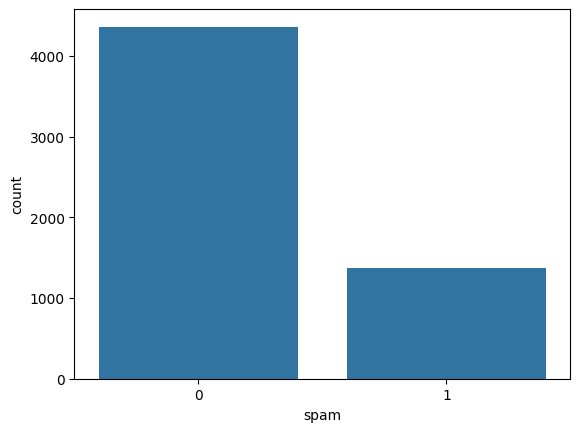

In [6]:
print(df['spam'].value_counts())
sns.countplot(x='spam', data=df)

In [7]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('','', string.punctuation))

df['text']= df['text'].apply(remove_punctuation)

In [8]:
df['text']= df['text'].str.lower()

In [9]:
df['text'].head()

0    subject naturally irresistible your corporate ...
1    subject the stock trading gunslinger  fanny is...
2    subject unbelievable new homes made easy  im w...
3    subject 4 color printing special  request addi...
4    subject do not have money  get software cds fr...
Name: text, dtype: object

In [10]:
def remove_number(text):
    new=''
    for i in text:
        if not i.isdigit():
            new=new+i
    return new
df['text']= df['text'].apply(remove_number)

In [11]:
df['text'].head()

0    subject naturally irresistible your corporate ...
1    subject the stock trading gunslinger  fanny is...
2    subject unbelievable new homes made easy  im w...
3    subject  color printing special  request addit...
4    subject do not have money  get software cds fr...
Name: text, dtype: object

In [12]:
def remove_links(text):
    new=''
    for i in text.split():
        if not i.startswith('http') and not i.startswith('www'):
            new=new+i+' '
    return new.strip()
df['text']= df['text'].apply(remove_links)

In [13]:
df['text'].head()

0    subject naturally irresistible your corporate ...
1    subject the stock trading gunslinger fanny is ...
2    subject unbelievable new homes made easy im wa...
3    subject color printing special request additio...
4    subject do not have money get software cds fro...
Name: text, dtype: object

In [14]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
stop_words= set(stopwords.words('english'))
len(stop_words)

198

In [15]:
def remove_stopwords(text):
    words= word_tokenize(text)
    cleaned_text=[]
    for i in words:
        if i not in stop_words:
            cleaned_text.append(i)
    return ' '.join(cleaned_text)

df['text']=df['text'].apply(remove_stopwords)

In [16]:
df['text'].head()

0    subject naturally irresistible corporate ident...
1    subject stock trading gunslinger fanny merrill...
2    subject unbelievable new homes made easy im wa...
3    subject color printing special request additio...
4    subject money get software cds software compat...
Name: text, dtype: object

In [17]:
df.shape

(5728, 2)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['spam'], test_size=0.33, random_state=42)

In [19]:
X_train.shape

(3837,)

In [20]:
X_test.shape

(1891,)

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer= CountVectorizer()
X_train_bow= bow_vectorizer.fit_transform(X_train)
X_test_bow= bow_vectorizer.transform(X_test)


In [22]:
from sklearn.naive_bayes import MultinomialNB

bow_nb_model= MultinomialNB()
bow_nb_model.fit(X_train_bow, y_train)

y_pred_bow= bow_nb_model.predict(X_test_bow)

In [23]:
from sklearn.metrics import classification_report,accuracy_score
print(accuracy_score(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_bow))

0.98783712321523
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1398
           1       0.98      0.97      0.98       493

    accuracy                           0.99      1891
   macro avg       0.99      0.98      0.98      1891
weighted avg       0.99      0.99      0.99      1891



In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer= TfidfVectorizer()

X_train_tf= tfidf_vectorizer.fit_transform(X_train)
X_test_tf= tfidf_vectorizer.transform(X_test)



In [25]:
tfidf_nb_model= MultinomialNB()

tfidf_nb_model.fit(X_train_tf,y_train)

y_pred_tf= tfidf_nb_model.predict(X_test_tf)

In [26]:
print(accuracy_score(y_test, y_pred_tf))

0.8757271285034374


In [27]:
print(f'Accuracy of Bow Model in Naive Bayes: {accuracy_score(y_test, y_pred_bow)}')
print(f'Accuracy of TF-IDF Model in Naive Bayes: {accuracy_score(y_test, y_pred_tf)}')

Accuracy of Bow Model in Naive Bayes: 0.98783712321523
Accuracy of TF-IDF Model in Naive Bayes: 0.8757271285034374


In [28]:
new_data= ['Congratulations! You have won a free ticket to the Bahamas. Click here to claim your prize.']

new_data_bow= bow_vectorizer.transform(new_data)

prediction= bow_nb_model.predict(new_data_bow)

In [29]:
print(prediction)

[1]


In [30]:
new_data_tf= tfidf_vectorizer.transform(new_data)

prediction_tf= tfidf_nb_model.predict(new_data_tf)

print(prediction_tf)

[0]


In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_bow= confusion_matrix(y_test, y_pred_bow)
cm_tf= confusion_matrix(y_test, y_pred_tf)
print(cm_bow)
print(cm_tf)

[[1388   10]
 [  13  480]]
[[1398    0]
 [ 235  258]]


In [32]:
import joblib

joblib.dump(bow_vectorizer, "vectorizer.joblib")
joblib.dump(bow_nb_model, "model.joblib")

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.
